# 3D Brain Tumor Segmentation — BraTS-PEDs

This notebook trains a **3D U-Net** to segment brain tumors from MRI scans.

**Project structure** (all complex logic lives in Python scripts):

| Module | Purpose |
|--------|---------|
| `brain_tumor_seg/config.py` | Paths and hyperparameters |
| `brain_tumor_seg/data/` | Dataset & DataLoaders |
| `brain_tumor_seg/models/` | 3D U-Net model |
| `brain_tumor_seg/visualization/` | 3-view visualizer with slider |
| `brain_tumor_seg/training/` | Training loop |
| `brain_tumor_seg/evaluation/` | Metrics & performance plots |

Each section below maps to one of those modules. The notebook only calls functions — no complex code here.

## 1. Setup & Configuration

Import the project modules and set the device (GPU if available).

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

# Add project root so we can import brain_tumor_seg
PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT))

# Drop cached project modules so edits to brain_tumor_seg take effect when this
# cell is re-run, instead of silently using the versions already imported.
for _module in [m for m in list(sys.modules) if m.startswith("brain_tumor_seg")]:
    del sys.modules[_module]

import torch
from brain_tumor_seg.config import (
    TRAIN_DIR, VAL_DIR, BATCH_SIZE, NUM_EPOCHS,
    LEARNING_RATE, TARGET_SHAPE, SEED, CHECKPOINT_DIR,
)
from brain_tumor_seg.utils.helpers import set_seed

set_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"Training data: {TRAIN_DIR}")
print(f"Validation data: {VAL_DIR}")

Device: cpu
Training data: C:\Cursor\Brain Cancer Segmentation\PKG - BraTS-PEDs-v1\BraTS-PEDs-v1\Training
Validation data: C:\Cursor\Brain Cancer Segmentation\PKG - BraTS-PEDs-v1\BraTS-PEDs-v1\Validation


## 2. DataLoader

Create DataLoaders for **training** and **validation**.

> **Note:** The official Validation folder has no segmentation masks, so validation metrics (Dice, loss) are computed on a held-out split from the Training folder. A separate inference loader loads the Validation folder for prediction on unseen cases.

In [2]:
from brain_tumor_seg.data import create_train_dataloader, create_val_dataloader

train_loader, val_loader = create_train_dataloader(
    train_dir=TRAIN_DIR,
    batch_size=BATCH_SIZE,
)

inference_loader = create_val_dataloader(
    val_dir=VAL_DIR,
    batch_size=BATCH_SIZE,
)

Training cases:   219
Validation cases: 38
Inference cases (Validation folder): 91


## 3. Visualizer

Browse a sample MRI volume in **three views** (axial, coronal, sagittal) using the interactive slice slider.

Red overlay = tumor mask (ground truth).

In [3]:
from brain_tumor_seg.visualization import show_volume_with_slider

# Load one sample from the training set
sample = train_loader.dataset[0]
image = sample["image"]   # shape: (4, D, H, W) — 4 MRI modalities
mask = sample["mask"]     # shape: (1, D, H, W) — binary tumor mask
case_id = sample["case_id"]

show_volume_with_slider(
    image=image,
    mask=mask,
    title=f"Case: {case_id}",
)

interactive(children=(IntSlider(value=48, continuous_update=False, description='Axial', max=95), IntSlider(val…

## 3b. Mask sanity check — one tumor or several?

A mask can look **split into separate pieces in one plane while looking solid in another**. That is normal:
a connected 3D shape produces disjoint 2D cross-sections whenever it is curved or lobed (slice across both
tips of a horseshoe and you see two blobs). The three panels above are also three *different* slice
locations, so they share almost no voxels and cannot be compared against each other.

The only way to settle it is **3D connected-component labelling**, below. Each component gets its own
colour, so two blobs sharing a colour are the same 3D mass.

3D connected-component analysis
  connectivity : 26-neighbour (faces + edges + corners, most permissive)
  volume shape : (96, 96, 96) (L-R, A-P, S-I)
  tumor voxels : 7,027
  components   : 1

  #1: 7,027 voxels, 100.0% of tumor, extent (22, 24, 43) at centroid (42.1, 52.8, 44.6)

  Verdict: one single connected mass. Any view where the mask looks split is a cross-section through a curved or lobed shape, not a gap in the segmentation.


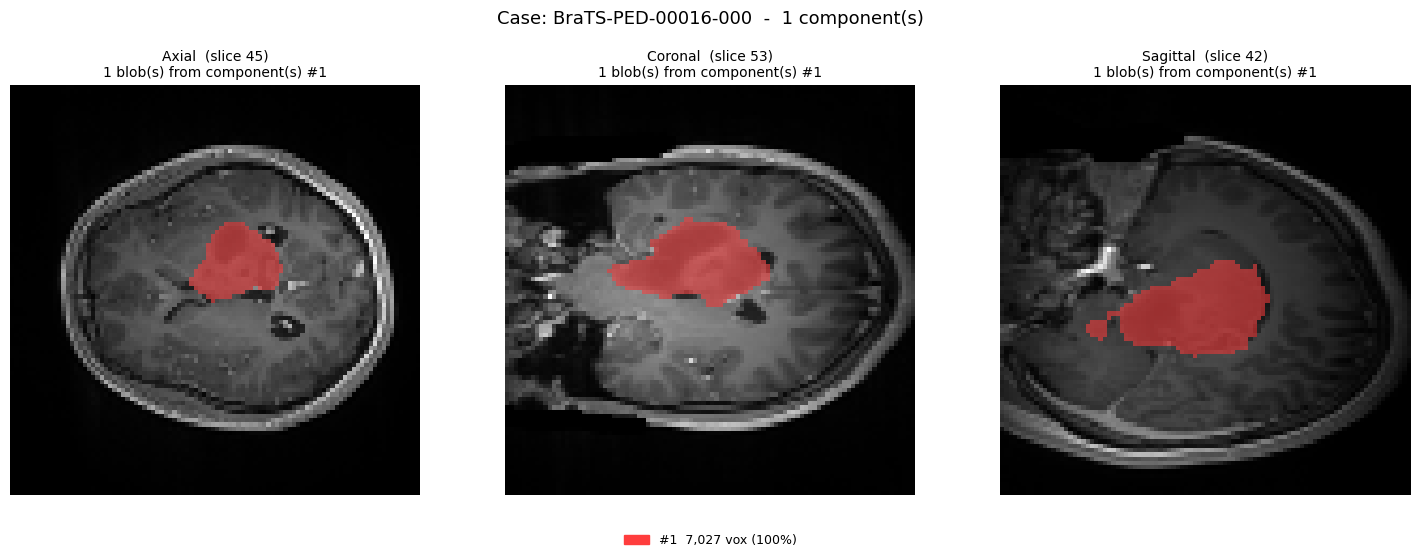

In [4]:
from brain_tumor_seg.utils import print_component_report
from brain_tumor_seg.visualization import plot_component_slices

# How many separate 3D masses are in this mask, and how far apart are they?
analysis = print_component_report(mask, connectivity=3)

# Same three planes, but each 3D component in its own colour.
# Views default to the centre of the largest component.
_ = plot_component_slices(image, mask, analysis=analysis, title=f"Case: {case_id}")

## 3C. 3D View

The same case as a rotatable **3D scene** instead of flat slices, stripped down to the anatomy alone:

- A **semi-transparent grey brain surface**, taken as an isosurface of the MRI intensity, so you can see inside the head.
- Each **tumor component as a solid coloured mesh**, using the same colours as the 2D component views above — component `#1` is the same red mass in both.

Nothing else: no tick numbers, no gridlines, no axis panes or bounding box, no legend — just the head shell and the tumor on white.

**How to interact.** The mode bar sits at the top-right of the scene:

| Gesture | Does |
|---------|------|
| **left-drag** | rotate (turntable) |
| **scroll wheel** | zoom in / out |
| **right-drag**, or **Ctrl + left-drag**, or the mode bar **Pan** button then left-drag | pan |
| **double-click** | reset the camera to the starting view |

`show_3d(fig)` is used instead of `fig.show()` because this environment's default Plotly renderer is `browser`, which opens the scene in a separate tab instead of drawing it in the output cell.

**To bring the axes and legend back**, pass `clean=False` (restores the anatomically labelled `L-R` / `A-P` / `S-I` axes with their ticks, grid and panes) and `show_legend=True` (legend entries also let you click a surface to hide it).

In [4]:
from brain_tumor_seg.visualization import show_volume_3d, show_3d, save_figure_html

# Reuses image, mask and case_id loaded in the visualizer cell above.
# min_voxels=10 drops the stray specks this case produces: the mask is resized
# 240**3 -> 96**3 by trilinear interpolation and then re-thresholded, which
# scatters one- and two-voxel fragments that would each become their own mesh.
fig_3d = show_volume_3d(image, mask, min_voxels=10, title=f"Case: {case_id}")

# show_3d, not fig.show(): renders inline in Cursor/VS Code with wheel zoom and
# the mode bar on. Add clean=False, show_legend=True above for labelled axes.
show_3d(fig_3d)

# To view it outside the notebook, write a standalone HTML file — it keeps the
# same rotate/zoom/pan behaviour:
# save_figure_html(fig_3d, "brain_3d_view.html")

## 4. Model

Create the 3D U-Net. It takes 4 MRI channels as input and outputs a tumor probability map.

In [6]:
from brain_tumor_seg.models import UNet3D

model = UNet3D(in_channels=4, out_channels=1)
model = model.to(device)

num_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {num_params:,}")

Model parameters: 1,402,561


## 5. Training Loop

Train the model for the configured number of epochs. Checkpoints are saved automatically when validation Dice improves.

In [7]:
from brain_tumor_seg.training import Trainer

trainer = Trainer(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    learning_rate=LEARNING_RATE,
    checkpoint_dir=CHECKPOINT_DIR,
)

history = trainer.train(num_epochs=NUM_EPOCHS)


Epoch 1/20
----------------------------------------


Train:   0%|          | 0/219 [00:00<?, ?it/s]

Val:   0%|          | 0/38 [00:00<?, ?it/s]

  Train Loss : 1.5408
  Val Loss   : 1.4577
  Val Dice   : 0.5605
  >> Saved best model (Dice=0.5605)

Epoch 2/20
----------------------------------------


Train:   0%|          | 0/219 [00:00<?, ?it/s]

...

Val:   0%|          | 0/38 [00:00<?, ?it/s]

  Train Loss : 0.6725
  Val Loss   : 0.6476
  Val Dice   : 0.8056
  >> Saved best model (Dice=0.8056)

Epoch 20/20
----------------------------------------


Train:   0%|          | 0/219 [00:00<?, ?it/s]

Val:   0%|          | 0/38 [00:00<?, ?it/s]

  Train Loss : 0.6010
  Val Loss   : 0.5808
  Val Dice   : 0.8141
  >> Saved best model (Dice=0.8141)


## 6. Evaluation

Plot **loss** and **Dice score** curves over training epochs.

In [7]:
from brain_tumor_seg.evaluation import plot_training_history, evaluate_model

plot_training_history(history)

metrics = evaluate_model(model, val_loader, device)
print(f"Final Val Loss: {metrics['loss']:.4f}")
print(f"Final Val Dice: {metrics['dice']:.4f}")

NameError: name 'history' is not defined

## 7. Inference & Visualization (Optional)

Load the best saved model and run prediction on a Validation case, then visualize the result with the slice slider.

In [ ]:
from brain_tumor_seg.evaluation import predict_volume
from brain_tumor_seg.visualization import show_volume_with_slider

# Load best checkpoint
trainer.load_checkpoint("best_model.pth")

# Get one case from the Validation folder (no ground-truth mask)
inf_sample = inference_loader.dataset[0]
inf_image = inf_sample["image"]
inf_case_id = inf_sample["case_id"]

# Predict tumor mask
predicted_mask = predict_volume(model, inf_image, device)

show_volume_with_slider(
    image=inf_image,
    mask=predicted_mask,
    title=f"Prediction — Case: {inf_case_id}",
)

### 7b. 3D Prediction View

The prediction from the cell above in the same **3D scene** as section 3C: translucent head shell, predicted tumor solid inside it, no axes or legend.

`min_voxels` matters more here than for ground truth. A thresholded model output is speckled with **spurious one- and two-voxel islands**, and every island would otherwise be drawn as its own coloured mesh, so the view fills up with confetti. Lower the value to inspect everything the model actually predicted.

Same gestures as above: left-drag rotates, scroll wheel zooms, right-drag (or `Ctrl` + left-drag, or the mode bar **Pan** button) pans, double-click resets the camera.

In [ ]:
from brain_tumor_seg.visualization import show_volume_3d, show_3d

# Reuses inf_image, predicted_mask and inf_case_id from the inference cell above.
# min_voxels=25 is deliberately stricter than the ground-truth view: predictions
# scatter far more spurious islands than a resized mask does.
fig_pred_3d = show_volume_3d(
    inf_image,
    predicted_mask,
    min_voxels=25,
    title=f"3D Prediction — Case: {inf_case_id}",
)

show_3d(fig_pred_3d)